Library import

In [1]:
print("="*80)
print("CELL 1: SETUP & INSTALLING LIBRARIES")
print("="*80)

import subprocess
import sys

# 📦 Install packages (Version constraints removed for torch & torchvision)
packages = [
    'transformers==4.35.0',
    'torch',
    'torchvision',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'tqdm',
    'pillow',
    'requests',
]

print("\n📦 Installing packages...")
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All packages installed!")

# 📥 Import everything
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AdamW,
    get_linear_schedule_with_warmup
)
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All imports successful!")

# 🖥️ Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

CELL 1: SETUP & INSTALLING LIBRARIES

📦 Installing packages...
✓ All packages installed!
✓ All imports successful!

🖥️ Device: cuda
   GPU: Tesla T4


MOUNT GOOGLE DRIVE

In [2]:
print("\n" + "="*80)
print(" MOUNT GOOGLE DRIVE")
print("="*80)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("\n✓ Google Drive mounted!")


 MOUNT GOOGLE DRIVE
Mounted at /content/drive

✓ Google Drive mounted!


LOAD & PREPARE DATASET

In [3]:
print("\n" + "="*80)
print("LOAD & PREPARE DATASET")
print("="*80)

# Path
DATASET_PATH = '/content/drive/MyDrive/Fake_News_Dataset499A/final_train_17k.tsv'
RESULTS_DIR = '/content/drive/MyDrive/Fake_News_Dataset499A/results'

os.makedirs(RESULTS_DIR, exist_ok=True)

# Load data
print(f"\n📊 Loading dataset from: {DATASET_PATH}")
df = pd.read_csv(DATASET_PATH, sep='\t')

print(f"✓ Loaded: {len(df)} samples")
print(f"  Columns: {df.columns.tolist()}")

# Prepare text data
print("\n📝 Preparing text data...")
df_text = df[['clean_title', '2_way_label']].copy()
df_text.columns = ['text', 'label']
df_text = df_text.dropna()
df_text['text'] = df_text['text'].astype(str)
df_text['label'] = df_text['label'].astype(int)

print(f"✓ Text samples: {len(df_text)}")
print(f"  Label distribution:\n{df_text['label'].value_counts()}")

# Split text data
train_text_df, test_text_df = train_test_split(
    df_text, test_size=0.2, random_state=42, stratify=df_text['label']
)

print(f"✓ Train: {len(train_text_df)}, Test: {len(test_text_df)}")

# Prepare image data
print("\n🖼️  Preparing image data...")
df_image = df[['image_url', '2_way_label']].copy()
df_image.columns = ['image_url', 'label']
df_image = df_image.dropna()
df_image['label'] = df_image['label'].astype(int)

print(f"✓ Image samples: {len(df_image)}")
print(f"  Label distribution:\n{df_image['label'].value_counts()}")

# Split image data
train_image_df, test_image_df = train_test_split(
    df_image, test_size=0.2, random_state=42, stratify=df_image['label']
)

print(f"✓ Train: {len(train_image_df)}, Test: {len(test_image_df)}")

# Store results
results_dict = {}

print("\n✅ Dataset ready!")


LOAD & PREPARE DATASET

📊 Loading dataset from: /content/drive/MyDrive/Fake_News_Dataset499A/final_train_17k.tsv
✓ Loaded: 17045 samples
  Columns: ['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']

📝 Preparing text data...
✓ Text samples: 17045
  Label distribution:
label
0    10404
1     6641
Name: count, dtype: int64
✓ Train: 13636, Test: 3409

🖼️  Preparing image data...
✓ Image samples: 17045
  Label distribution:
label
0    10404
1     6641
Name: count, dtype: int64
✓ Train: 13636, Test: 3409

✅ Dataset ready!


TRAIN TEXT MODEL 1 - mBERT

In [4]:
print("\n" + "="*80)
print("TRAIN TEXT MODEL 1 - mBERT")
print("="*80)

# Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = [str(t) for t in texts]
        self.labels = [int(l) for l in labels]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Training function
def train_text_model(model, train_loader, test_loader, model_name, epochs=2):
    print(f"\n🤖 Training {model_name}...")

    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    for epoch in range(epochs):
        # Train
        model.train()
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        # Eval
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1} Eval", leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # Final eval
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)

    return {'accuracy': float(accuracy), 'f1': float(f1), 'precision': float(precision), 'recall': float(recall)}

# Train mBERT
model_name = "bert-base-multilingual-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = TextDataset(train_text_df['text'].values, train_text_df['label'].values, tokenizer)
test_dataset = TextDataset(test_text_df['text'].values, test_text_df['label'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
results_dict['mBERT'] = train_text_model(model, train_loader, test_loader, model_name)

print(f"\n✅ mBERT: {results_dict['mBERT']}")



TRAIN TEXT MODEL 1 - mBERT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🤖 Training bert-base-multilingual-uncased...


  Accuracy: 0.8366, F1: 0.8006


  Accuracy: 0.8542, F1: 0.8179

✅ mBERT: {'accuracy': 0.8542094455852156, 'f1': 0.817882008061561, 'precision': 0.7965738758029979, 'recall': 0.8403614457831325}


TRAIN TEXT MODEL 2 - BERT-base

In [5]:
print("\n" + "="*80)
print("TRAIN TEXT MODEL 2 - BERT-base-uncased")
print("="*80)

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = TextDataset(train_text_df['text'].values, train_text_df['label'].values, tokenizer)
test_dataset = TextDataset(test_text_df['text'].values, test_text_df['label'].values, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
results_dict['BERT-base-uncased'] = train_text_model(model, train_loader, test_loader, model_name)

print(f"\n✅ BERT-base-uncased: {results_dict['BERT-base-uncased']}")


TRAIN TEXT MODEL 2 - BERT-base-uncased


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🤖 Training bert-base-uncased...


  Accuracy: 0.8530, F1: 0.8152


  Accuracy: 0.8566, F1: 0.8177

✅ BERT-base-uncased: {'accuracy': 0.8565561748313288, 'f1': 0.8177413343272456, 'precision': 0.8095940959409594, 'recall': 0.8260542168674698}


TRAIN TEXT MODEL 3 - TF-IDF

In [6]:
print("\n" + "="*80)
print("TRAIN TEXT MODEL 3 - TF-IDF + Logistic Regression")
print("="*80)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_text_df['text'])
X_test = vectorizer.transform(test_text_df['text'])

lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train, train_text_df['label'])

preds = lr_model.predict(X_test)
accuracy = accuracy_score(test_text_df['label'], preds)
f1 = f1_score(test_text_df['label'], preds, zero_division=0)
precision = precision_score(test_text_df['label'], preds, zero_division=0)
recall = recall_score(test_text_df['label'], preds, zero_division=0)

results_dict['TF-IDF + LogReg'] = {
    'accuracy': float(accuracy), 'f1': float(f1),
    'precision': float(precision), 'recall': float(recall)
}

print(f"✅ TF-IDF: {results_dict['TF-IDF + LogReg']}")


TRAIN TEXT MODEL 3 - TF-IDF + Logistic Regression
✅ TF-IDF: {'accuracy': 0.7714872396597242, 'f1': 0.6829466829466829, 'precision': 0.7431355181576617, 'recall': 0.6317771084337349}


TRAIN IMAGE MODEL 1 - ViT

In [7]:
print("\n" + "="*80)
print("TRAIN IMAGE MODEL 1 - Vision Transformer (ViT)")
print("="*80)

# Image dataset class
class ImageDataset(Dataset):
    def __init__(self, urls, labels, transform=None):
        self.urls = list(urls)
        self.labels = [int(l) for l in labels]
        self.transform = transform

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = str(self.urls[idx])
        label = self.labels[idx]

        try:
            response = requests.get(url, timeout=5)
            image = Image.open(BytesIO(response.content)).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='gray')

        if self.transform:
            image = self.transform(image)

        return {'image': image, 'label': torch.tensor(label, dtype=torch.long)}

# Image transform
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Training function for images
def train_image_model(model, train_loader, test_loader, model_name, epochs=2):
    print(f"\n🤖 Training {model_name}...")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        # Train
        model.train()
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        # Eval
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1} Eval", leave=False):
                images = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(images)
                if hasattr(outputs, 'logits'):
                    logits = outputs.logits
                else:
                    logits = outputs
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # Final eval
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images)
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)

    return {'accuracy': float(accuracy), 'f1': float(f1), 'precision': float(precision), 'recall': float(recall)}

# Create datasets
train_img_dataset = ImageDataset(train_image_df['image_url'].values, train_image_df['label'].values, image_transform)
test_img_dataset = ImageDataset(test_image_df['image_url'].values, test_image_df['label'].values, image_transform)

train_img_loader = DataLoader(train_img_dataset, batch_size=16, shuffle=True, num_workers=2)
test_img_loader = DataLoader(test_img_dataset, batch_size=16, shuffle=False, num_workers=2)

# ViT model
vit_model = models.vit_b_16(pretrained=True)
num_ftrs = vit_model.heads[0].in_features
vit_model.heads[0] = nn.Linear(num_ftrs, 2)
vit_model = vit_model.to(device)

results_dict['ViT'] = train_image_model(vit_model, train_img_loader, test_img_loader, "ViT")
print(f"\n✅ ViT: {results_dict['ViT']}")


TRAIN IMAGE MODEL 1 - Vision Transformer (ViT)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 175MB/s]



🤖 Training ViT...


  Accuracy: 0.7688, F1: 0.7372


  Accuracy: 0.7580, F1: 0.6939



✅ ViT: {'accuracy': 0.7579935464945732, 'f1': 0.6938775510204082, 'precision': 0.6839795171909291, 'recall': 0.704066265060241}


TRAIN IMAGE MODEL 2 - EfficientNet-B0

In [8]:
print("\n" + "="*80)
print("TRAIN IMAGE MODEL 2 - EfficientNet-B0")
print("="*80)

enet_model = models.efficientnet_b0(pretrained=True)
num_ftrs = enet_model.classifier[1].in_features
enet_model.classifier[1] = nn.Linear(num_ftrs, 2)
enet_model = enet_model.to(device)

results_dict['EfficientNet-B0'] = train_image_model(enet_model, train_img_loader, test_img_loader, "EfficientNet-B0")
print(f"\n✅ EfficientNet-B0: {results_dict['EfficientNet-B0']}")


TRAIN IMAGE MODEL 2 - EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]



🤖 Training EfficientNet-B0...


  Accuracy: 0.8184, F1: 0.7897


  Accuracy: 0.8208, F1: 0.7967



✅ EfficientNet-B0: {'accuracy': 0.8207685538281021, 'f1': 0.7966722129783694, 'precision': 0.7137745974955277, 'recall': 0.901355421686747}


TRAIN IMAGE MODEL 3 - ResNet50

In [9]:
print("\n" + "="*80)
print("TRAIN IMAGE MODEL 3 - ResNet50")
print("="*80)

resnet_model = models.resnet50(pretrained=True)
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 2)
resnet_model = resnet_model.to(device)

results_dict['ResNet50'] = train_image_model(resnet_model, train_img_loader, test_img_loader, "ResNet50")
print(f"\n✅ ResNet50: {results_dict['ResNet50']}")


TRAIN IMAGE MODEL 3 - ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]



🤖 Training ResNet50...


  Accuracy: 0.7832, F1: 0.7731


  Accuracy: 0.7870, F1: 0.7638



✅ ResNet50: {'accuracy': 0.7870343209152244, 'f1': 0.763825634352635, 'precision': 0.6723940435280642, 'recall': 0.8840361445783133}


TRAIN XLM-RoBERTa (Main Model)

In [15]:
print("\n" + "="*80)
print("TRAIN XLM-RoBERTa")
print("="*80)

# ===== IMPORTS =====
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm

# ===== DEFINE TEXTDATASET CLASS (needed!) =====
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = [str(t) for t in texts]
        self.labels = [int(l) for l in labels]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ===== DEFINE TRAINING FUNCTION =====
def train_text_model(model, train_loader, test_loader, model_name, epochs=2):
    print(f"\n🤖 Training {model_name}...")

    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    for epoch in range(epochs):
        # Train
        model.train()
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        # Eval
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1} Eval", leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # Final eval
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)

    return {'accuracy': float(accuracy), 'f1': float(f1), 'precision': float(precision), 'recall': float(recall)}

# ===== TRAIN XLM-RoBERTa =====
print("\n🤖 Loading XLM-RoBERTa...")
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("✓ Creating datasets...")
train_dataset = TextDataset(train_text_df['text'].values, train_text_df['label'].values, tokenizer)
test_dataset = TextDataset(test_text_df['text'].values, test_text_df['label'].values, tokenizer)

print("✓ Creating data loaders...")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("✓ Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

print("✓ Model ready!")

# Train
results_dict['XLM-RoBERTa'] = train_text_model(model, train_loader, test_loader, model_name, epochs=3)

print(f"\n✅ XLM-RoBERTa: {results_dict['XLM-RoBERTa']}")


# ============================================================================
# SAVE TRAINED XLM-RoBERTa - DO THIS IN CELL 19!
# ============================================================================

import os
import torch

print("\n" + "="*80)
print("SAVING TRAINED XLM MODEL FROM CELL 19")
print("="*80)

# Create results folder
results_folder = '/content/drive/MyDrive/Fake_News_Dataset499A/results'
os.makedirs(results_folder, exist_ok=True)

# Get the trained model (from CELL 19 training)
trained_model = model  # This is the trained model!

# Save it
xlm_path = f'{results_folder}/xlm_roberta_trained.pt'

print(f"\nSaving trained XLM-RoBERTa to: {xlm_path}")
torch.save(trained_model.state_dict(), xlm_path)

# Verify it was saved
if os.path.exists(xlm_path):
    size = os.path.getsize(xlm_path) / 1e9
    print(f"✅ SUCCESS! File saved: {size:.2f} GB")
else:
    print(f"❌ ERROR: File not saved!")

print("="*80)
# Save ResNet50 (trained from CELL 17)
print("\n🖼️ Saving ResNet50...")
resnet_path = f'{results_folder}/resnet_trained.pt'
torch.save(resnet_model.state_dict(), resnet_path)

if os.path.exists(resnet_path):
    size = os.path.getsize(resnet_path) / 1e6
    print(f"   ✅ ResNet Saved: {size:.0f} MB")
else:
    print(f"   ❌ ResNet Save failed!")


TRAIN XLM-RoBERTa

🤖 Loading XLM-RoBERTa...
✓ Creating datasets...
✓ Creating data loaders...
✓ Loading model...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model ready!

🤖 Training xlm-roberta-base...


  Accuracy: 0.8187, F1: 0.7341


  Accuracy: 0.8354, F1: 0.8039


  Accuracy: 0.8483, F1: 0.8047

✅ XLM-RoBERTa: {'accuracy': 0.8483426224699325, 'f1': 0.8046845485455232, 'precision': 0.8074298711144806, 'recall': 0.8019578313253012}

SAVING TRAINED XLM MODEL FROM CELL 19

Saving trained XLM-RoBERTa to: /content/drive/MyDrive/Fake_News_Dataset499A/results/xlm_roberta_trained.pt
✅ SUCCESS! File saved: 1.11 GB

🖼️ Saving ResNet50...
   ✅ ResNet Saved: 94 MB


LATE FUSION - XLM-RoBERTa + ResNet50

In [16]:
print("\n" + "="*80)
print("LATE FUSION - XLM-RoBERTa + ResNet50")
print("="*80)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm

print("\n🤖 Loading models for fusion...")

# ===== Load XLM-RoBERTa =====
print("  Loading XLM-RoBERTa...")
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
xlm_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
xlm_model.eval()
print("  ✓ XLM-RoBERTa loaded!")

# ===== ResNet50 already trained =====
print("  ResNet50 already available from CELL 9!")
resnet_model.eval()

# ===== Get Predictions =====
print("\n📊 Getting predictions from both models...")

text_preds = []
image_preds = []
true_labels = []

# Create loaders again (for this cell)
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = [str(t) for t in texts]
        self.labels = [int(l) for l in labels]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create text dataset and loader
print("  Creating text dataset...")
test_text_dataset = TextDataset(test_text_df['text'].values, test_text_df['label'].values, tokenizer)
test_text_loader = DataLoader(test_text_dataset, batch_size=16, shuffle=False)

# Get text predictions
print("  Getting XLM predictions...")
with torch.no_grad():
    for batch in tqdm(test_text_loader, desc="Text predictions", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = xlm_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        text_preds.extend(probs.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("  ✓ Text predictions done!")

# Get image predictions
print("  Getting ResNet predictions...")
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from io import BytesIO
import requests

class ImageDataset(Dataset):
    def __init__(self, urls, labels, transform=None):
        self.urls = list(urls)
        self.labels = [int(l) for l in labels]
        self.transform = transform

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = str(self.urls[idx])
        label = self.labels[idx]

        try:
            response = requests.get(url, timeout=5)
            image = Image.open(BytesIO(response.content)).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='gray')

        if self.transform:
            image = self.transform(image)

        return {'image': image, 'label': torch.tensor(label, dtype=torch.long)}

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_image_dataset = ImageDataset(test_image_df['image_url'].values, test_image_df['label'].values, image_transform)
test_image_loader = DataLoader(test_image_dataset, batch_size=16, shuffle=False, num_workers=2)

with torch.no_grad():
    for batch in tqdm(test_image_loader, desc="Image predictions", leave=False):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = resnet_model(images)
        probs = torch.softmax(outputs, dim=1)
        image_preds.extend(probs.cpu().numpy())

print("  ✓ Image predictions done!")

# ===== Late Fusion =====
print("\n🔀 Performing Late Fusion...")

text_preds = np.array(text_preds[:len(true_labels)])
image_preds = np.array(image_preds[:len(true_labels)])

print(f"  Text predictions shape: {text_preds.shape}")
print(f"  Image predictions shape: {image_preds.shape}")
print(f"  True labels shape: {len(true_labels)}")

# Average predictions (Late Fusion)
fusion_preds = (text_preds + image_preds) / 2
fusion_pred_labels = np.argmax(fusion_preds, axis=1)

print("  ✓ Fusion completed!")

# ===== Evaluate Fusion =====
print("\n📊 Evaluating Fusion Model...")

accuracy = accuracy_score(true_labels, fusion_pred_labels)
f1 = f1_score(true_labels, fusion_pred_labels, zero_division=0)
precision = precision_score(true_labels, fusion_pred_labels, zero_division=0)
recall = recall_score(true_labels, fusion_pred_labels, zero_division=0)

results_dict['Late Fusion (XLM+ResNet50)'] = {
    'accuracy': float(accuracy), 'f1': float(f1),
    'precision': float(precision), 'recall': float(recall)
}

print(f"✅ Late Fusion Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")

print(f"\n✅ Complete: {results_dict['Late Fusion (XLM+ResNet50)']}")


LATE FUSION - XLM-RoBERTa + ResNet50

🤖 Loading models for fusion...
  Loading XLM-RoBERTa...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✓ XLM-RoBERTa loaded!
  ResNet50 already available from CELL 9!

📊 Getting predictions from both models...
  Creating text dataset...
  Getting XLM predictions...


  ✓ Text predictions done!
  Getting ResNet predictions...


  ✓ Image predictions done!

🔀 Performing Late Fusion...
  Text predictions shape: (3409, 2)
  Image predictions shape: (3409, 2)
  True labels shape: 3409
  ✓ Fusion completed!

📊 Evaluating Fusion Model...
✅ Late Fusion Results:
  Accuracy:  0.7891
  F1-Score:  0.7650
  Precision: 0.6759
  Recall:    0.8810

✅ Complete: {'accuracy': 0.7890877090055735, 'f1': 0.7649558679306963, 'precision': 0.6759098786828422, 'recall': 0.8810240963855421}


COMPARISON & VISUALIZATION

In [17]:
print("\n" + "="*80)
print("RESULTS COMPARISON & VISUALIZATION")
print("="*80)

# Create DataFrame
results_df = pd.DataFrame(results_dict).T
results_df = results_df.round(4)

print("\n📊 FINAL RESULTS TABLE:")
print("="*80)
print(results_df.to_string())
print("="*80)

# Save results
json_file = f'{RESULTS_DIR}/complete_results.json'
with open(json_file, 'w') as f:
    json.dump(results_dict, f, indent=4)

csv_file = f'{RESULTS_DIR}/complete_results.csv'
results_df.to_csv(csv_file)

print(f"\n✓ Results saved:")
print(f"  JSON: {json_file}")
print(f"  CSV: {csv_file}")


RESULTS COMPARISON & VISUALIZATION

📊 FINAL RESULTS TABLE:
                            accuracy      f1  precision  recall
mBERT                         0.8542  0.8179     0.7966  0.8404
BERT-base-uncased             0.8566  0.8177     0.8096  0.8261
TF-IDF + LogReg               0.7715  0.6829     0.7431  0.6318
ViT                           0.7580  0.6939     0.6840  0.7041
EfficientNet-B0               0.8208  0.7967     0.7138  0.9014
ResNet50                      0.7870  0.7638     0.6724  0.8840
XLM-RoBERTa                   0.8483  0.8047     0.8074  0.8020
Late Fusion (XLM+ResNet50)    0.7891  0.7650     0.6759  0.8810

✓ Results saved:
  JSON: /content/drive/MyDrive/Fake_News_Dataset499A/results/complete_results.json
  CSV: /content/drive/MyDrive/Fake_News_Dataset499A/results/complete_results.csv


CREATE COMPARISON CHARTS


CREATE COMPARISON CHARTS

✓ Chart saved: /content/drive/MyDrive/Fake_News_Dataset499A/results/complete_comparison.png


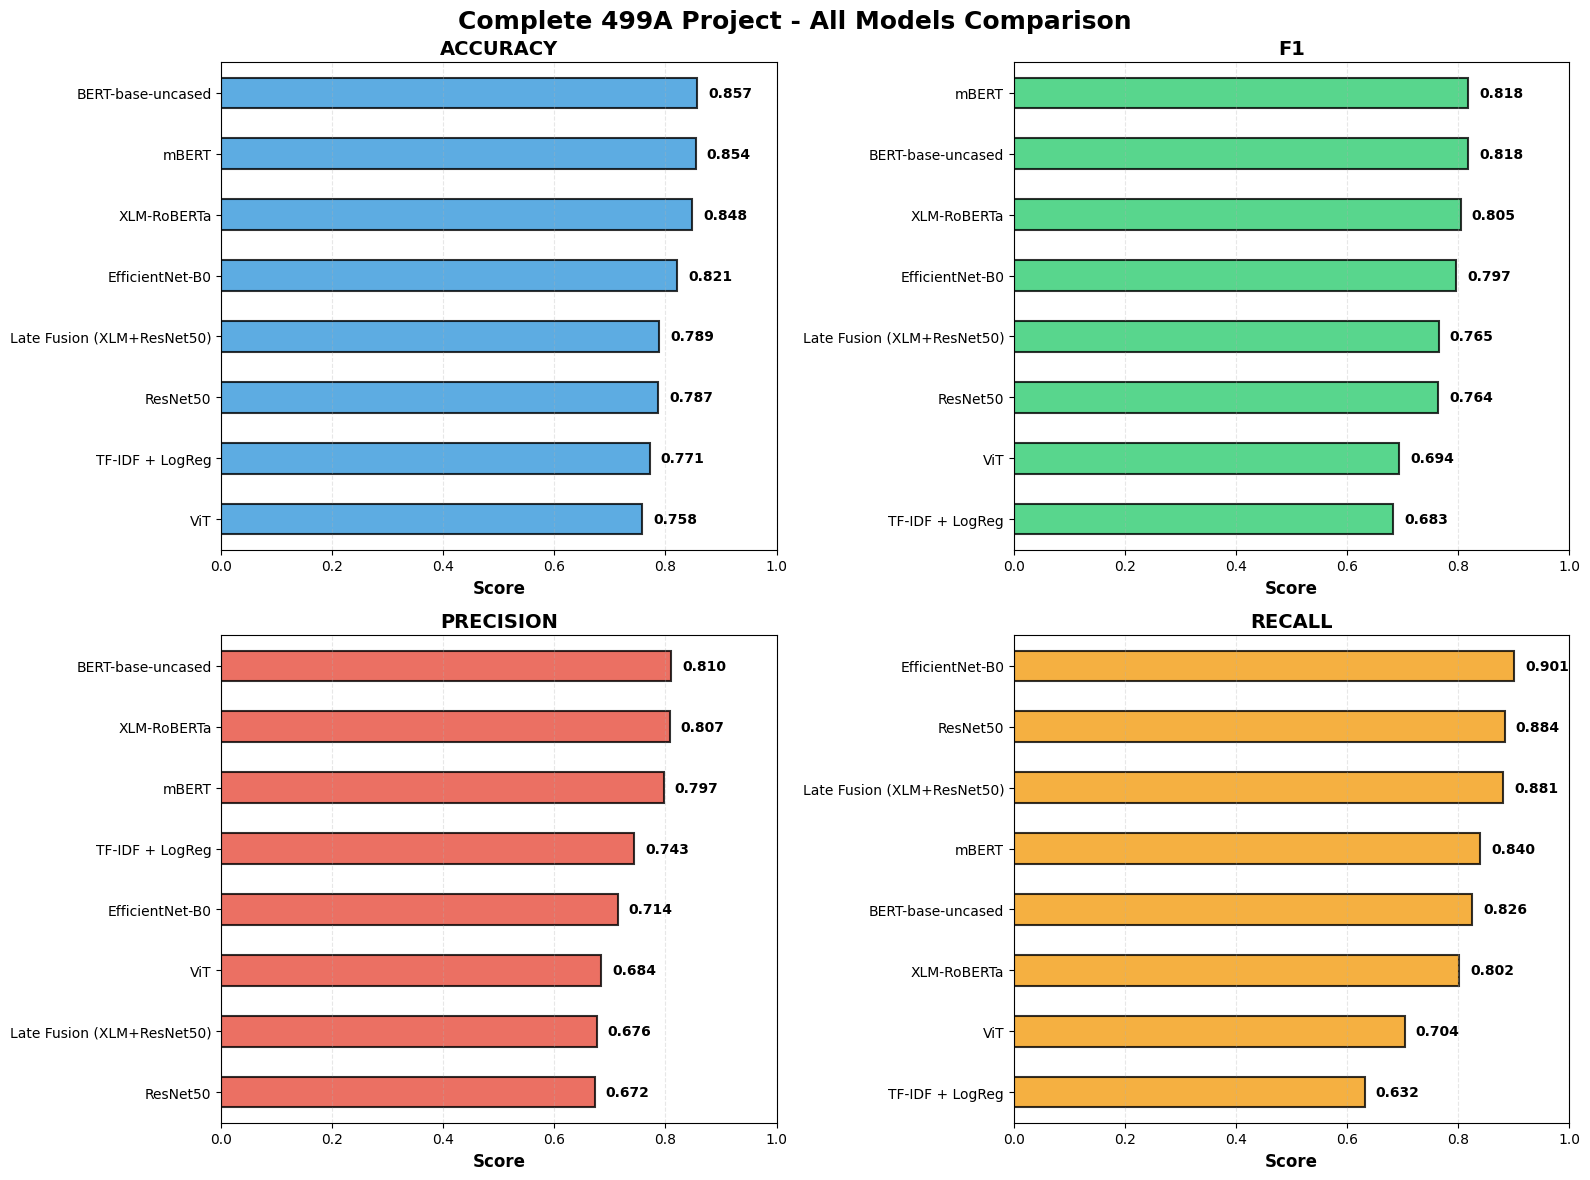


✅ VISUALIZATION COMPLETE!


In [18]:
print("\n" + "="*80)
print("CREATE COMPARISON CHARTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Complete 499A Project - All Models Comparison', fontsize=18, fontweight='bold')

metrics = ['accuracy', 'f1', 'precision', 'recall']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]

    sorted_data = results_df[metric].sort_values()
    sorted_data.plot(kind='barh', ax=ax, color=color, alpha=0.8, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric.upper()}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Score', fontweight='bold', fontsize=12)
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    for i, v in enumerate(sorted_data):
        ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()

png_file = f'{RESULTS_DIR}/complete_comparison.png'
plt.savefig(png_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {png_file}")

plt.show()

print("\n✅ VISUALIZATION COMPLETE!")

Model Saving with weight

In [19]:
import torch
import os

print("\n" + "="*80)
print("VERIFYING SAVED WEIGHTS")
print("="*80)

# Check files exist
xlm_path = '/content/drive/MyDrive/Fake_News_Dataset499A/results/xlm_roberta_trained.pt'
resnet_path = '/content/drive/MyDrive/Fake_News_Dataset499A/results/resnet_trained.pt'

print("\n1️⃣ File Verification:")
if os.path.exists(xlm_path):
    xlm_size = os.path.getsize(xlm_path) / 1e9
    print(f"   ✅ XLM file exists: {xlm_size:.2f} GB")
else:
    print(f"   ❌ XLM file NOT found!")

if os.path.exists(resnet_path):
    resnet_size = os.path.getsize(resnet_path) / 1e6
    print(f"   ✅ ResNet file exists: {resnet_size:.0f} MB")
else:
    print(f"   ❌ ResNet file NOT found!")

# Test load
print("\n2️⃣ Testing Load:")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    xlm_state = torch.load(xlm_path, map_location=device)
    print(f"   ✅ XLM weights load OK")
    print(f"   📊 State dict keys: {len(xlm_state)}")
except Exception as e:
    print(f"   ❌ XLM load error: {e}")

try:
    resnet_state = torch.load(resnet_path, map_location=device)
    print(f"   ✅ ResNet weights load OK")
    print(f"   📊 State dict keys: {len(resnet_state)}")
except Exception as e:
    print(f"   ❌ ResNet load error: {e}")

# Test inference
print("\n3️⃣ Testing Inference:")
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torchvision import models
import torch.nn as nn

# Load fresh XLM and test
try:
    test_xlm = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)
    test_xlm.load_state_dict(xlm_state, strict=False)
    test_xlm = test_xlm.to(device)
    test_xlm.eval()

    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    test_text = "This is a test"
    inputs = tokenizer(test_text, return_tensors='pt', max_length=128, padding='max_length', truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output = test_xlm(**inputs)
        logits = output.logits[0].cpu().numpy()

    print(f"   ✅ XLM inference OK")
    print(f"   📊 Logits: {logits}")
    max_logit = max(abs(logits[0]), abs(logits[1]))
    if max_logit > 1.0:
        print(f"   ✅ Logits look TRAINED (values high)")
    else:
        print(f"   ❌ Logits look UNTRAINED (values near 0)")
except Exception as e:
    print(f"   ❌ XLM inference error: {e}")

# Load fresh ResNet and test
try:
    test_resnet = models.resnet50(pretrained=True)
    num_ftrs = test_resnet.fc.in_features
    test_resnet.fc = nn.Linear(num_ftrs, 2)
    test_resnet.load_state_dict(resnet_state, strict=False)
    test_resnet = test_resnet.to(device)
    test_resnet.eval()

    import torch
    test_image = torch.randn(1, 3, 224, 224).to(device)

    with torch.no_grad():
        output = test_resnet(test_image)
        logits = output[0].cpu().numpy()

    print(f"\n   ✅ ResNet inference OK")
    print(f"   📊 Logits: {logits}")
    max_logit = max(abs(logits[0]), abs(logits[1]))
    if max_logit > 0.1:
        print(f"   ✅ Logits look TRAINED (values high)")
    else:
        print(f"   ❌ Logits look UNTRAINED (values near 0)")
except Exception as e:
    print(f"   ❌ ResNet inference error: {e}")

print("\n" + "="*80)


VERIFYING SAVED WEIGHTS

1️⃣ File Verification:
   ✅ XLM file exists: 1.11 GB
   ✅ ResNet file exists: 94 MB

2️⃣ Testing Load:
   ✅ XLM weights load OK
   📊 State dict keys: 201
   ✅ ResNet weights load OK
   📊 State dict keys: 320

3️⃣ Testing Inference:


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✅ XLM inference OK
   📊 Logits: [ 2.3410227 -1.9669764]
   ✅ Logits look TRAINED (values high)

   ✅ ResNet inference OK
   📊 Logits: [ 6.7663856 -5.1807637]
   ✅ Logits look TRAINED (values high)

